# **TALLER: Predicción del precio de carros**


**Parte 1 – Comprensión del problema**

**- Variable objetivo**

La variable objetivo de este taller es **"price"**, ya que el propósito es predecir el precio de un automóvil a partir de sus características (como los caballos de fuerza, la marca, el tipo de tracción, etc)

**- ¿Regresión o clasificación? ¿Por qué?**

Es un problema de regresión, porque se quiere predecir un valor numérico y continuo (el precio), no una categoría o etiqueta (como el color, el tipo de combustible o la marca)

**- Contexto del problema**

Se desea entender qué factores determinan el precio de los automóviles en un mercado determinado, y para esto, se hace uso de un modelo de machine learning, con el fin de predecir el posible costo en el futuro. 


In [27]:
# Primero, importamos las librerías necesarias para desarollar la actividad 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler


In [28]:
# Ahora, cargamos el data set

df = pd.read_csv('CarPrice_Assignment.csv')
print("Dimensiones del dataset:", df.shape)

# Damos un vistazo general al DataFrame con .head()

df.head(20)


Dimensiones del dataset: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.000
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.000
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.000
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.000
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.000
5,6,2,audi fox,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250.000
6,7,1,audi 100ls,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710.000
7,8,1,audi 5000,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920.000
8,9,1,audi 4000,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875.000
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,17859.167


In [29]:
# Hacemos un breve análisis de las columnas, los dtypes yla cuenta de los nulos con .info()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

**Parte 2 – Exploración de datos (EDA básica)**

In [30]:
# Buscamos la cantidad de los valores nulos

print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nEl total de valores nulos en el dataset resulta ser", df.isnull().sum().sum())


Valores nulos por columna:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

El total de valores nulos en el dataset resulta ser 0


In [31]:
# Identificamos las variables numéricas y las variables categóricas

VariablesNuméricas = df.select_dtypes(include=['number']).columns.tolist()
VariablesCategóricas = df.select_dtypes(exclude=['number']).columns.tolist()

print(F'Las variables númericas son {VariablesNuméricas},\nmientras que las categóricas son {VariablesCategóricas}')

Las variables númericas son ['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
mientras que las categóricas son ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


In [32]:
# Se revisan los datos estadísticos básicos de la variable objetivo
df['price'].describe()

count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: price, dtype: float64

**Gráfico 1**

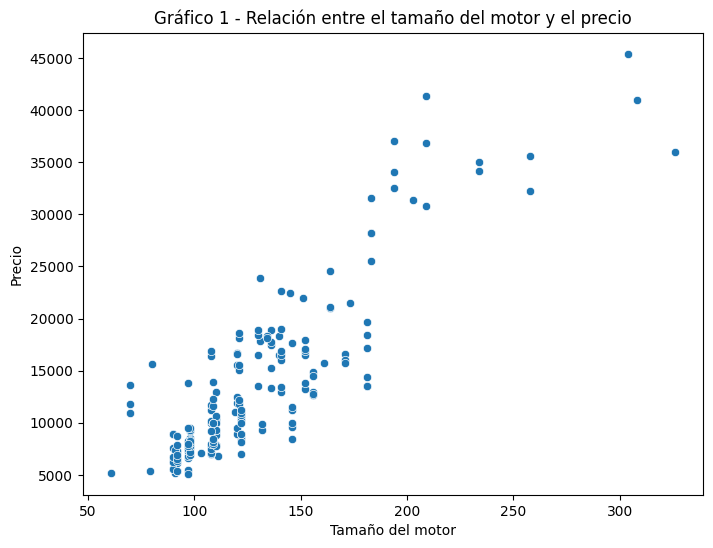

In [33]:

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='enginesize', y='price')
plt.title('Gráfico 1 - Relación entre el tamaño del motor y el precio')
plt.xlabel('Tamaño del motor')
plt.ylabel('Precio')
plt.show()


Podemos observar que a mayor tamaño del motor, mayor es el precio. Esto nos sirve para analizar visualmente la linealidad de la variable.

 **Gráfico 2**

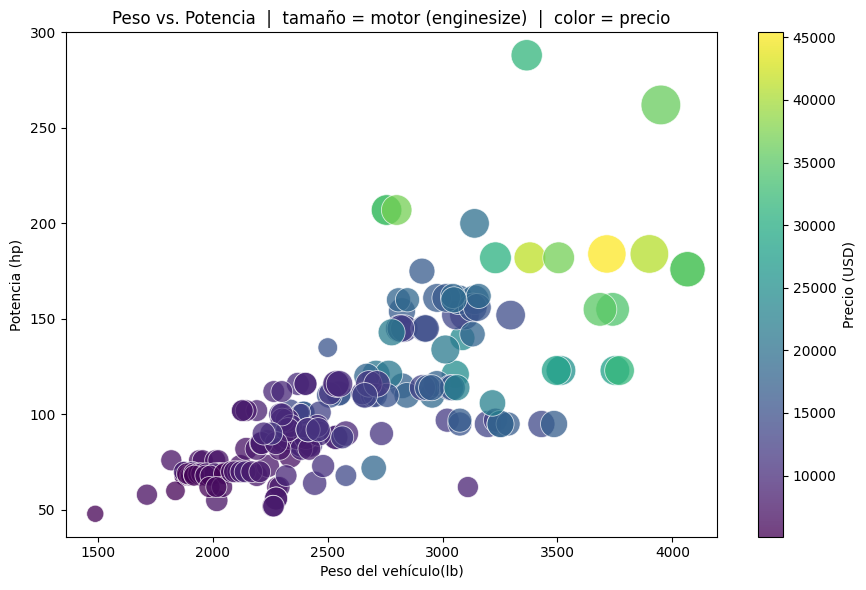

price         1.000000
enginesize    0.874145
curbweight    0.835305
horsepower    0.808139
Name: price, dtype: float64

In [34]:
fig, ax = plt.subplots(figsize=(9,6))

bubble = ax.scatter(
    df['curbweight'], df['horsepower'],
    s=df['enginesize'] * 2.5,          
    c=df['price'], cmap='viridis',      
    alpha=0.75, edgecolors='white', linewidth=0.6
)

cbar = plt.colorbar(bubble, ax=ax)
cbar.set_label('Precio (USD)')
ax.set_xlabel('Peso del vehículo(lb)')
ax.set_ylabel('Potencia (hp)')
ax.set_title('Peso vs. Potencia  |  tamaño = motor (enginesize)  |  color = precio')
plt.tight_layout()
plt.show()
df[['curbweight', 'horsepower', 'enginesize', 'price']].corr()['price'].sort_values(ascending=False)


Aquí se combinan cuatro variables: los vehículos más pesados (eje X) tienden a tener también más potencia (eje Y), motores más grandes, (representados por las burbujas más grandes) y precios más altos . La nube de puntos morados y pequeños en la esquina inferior izquierda corresponde a los autos económicos, mientras que las burbujas grandes y amarillas de la esquina superior derecha son los vehículos de lujo.

 **Gráfico 3** 

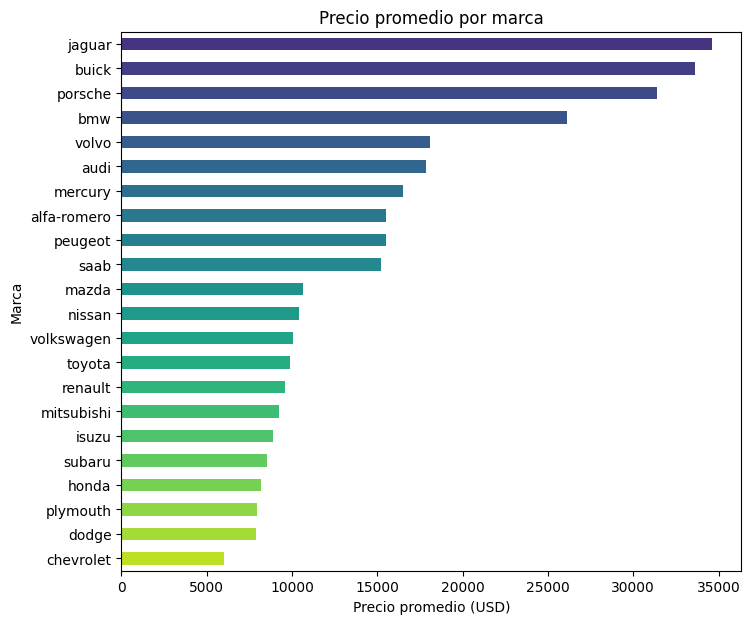

In [35]:
# Se extrae temporalmente la marca (a partir de CarName) solo para explorar el precio promedio.
# El manejo de errores de escritura y valores únicos se hace en la parte tres.

typo_map_eda = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
}
brand_temp = df['CarName'].str.split(' ').str[0].str.lower().replace(typo_map_eda)

avg_price_brand = df.groupby(brand_temp)['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,7))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(avg_price_brand)))
avg_price_brand.plot(kind='barh', color=colors)
plt.gca().invert_yaxis()
plt.title('Precio promedio por marca')
plt.xlabel('Precio promedio (USD)')
plt.ylabel('Marca')
plt.show()



Se observa una brecha muy marcada según la marca, puesto que Jaguar, Buick, Porsche y BMW tienen un precio promedio superior a 25.000 USD, mientras que marcas más populares y económicas como Chevrolet, Dodge y Plymouth promedian entre 6.000 y 8.000 USD. Esto sugiere que, incluso antes de mirar variables técnicas, la marca por sí sola ya explica buena parte de la variabilidad del precio.

**Parte 3 – Preparación de datos**


Se hacen las correcciones pertinentes de los errores de escritura y de valores únicos provenientes de la mezcla entre el nombre de modelo y la marca en la misma celda.

In [36]:
df['brand'] = df['CarName'].str.split(' ').str[0].str.lower()

typo_map = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
}
df['brand'] = df['brand'].replace(typo_map)

print(f"Después de la limpieza quedan {df['brand'].nunique()} marcas, que son:")
sorted(df['brand'].unique())


Después de la limpieza quedan 22 marcas, que son:


['alfa-romero',
 'audi',
 'bmw',
 'buick',
 'chevrolet',
 'dodge',
 'honda',
 'isuzu',
 'jaguar',
 'mazda',
 'mercury',
 'mitsubishi',
 'nissan',
 'peugeot',
 'plymouth',
 'porsche',
 'renault',
 'saab',
 'subaru',
 'toyota',
 'volkswagen',
 'volvo']

Las columnas que no aportan nada al modelo predictivo se eliminan. En este caso, "car_ID" y "Car Name" (que se remplaza por "brand").

In [37]:
df1 = df.drop(columns=['car_ID', 'CarName'])
df1.head()


,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi



Aquí podemos aplicar One-Hot Encoding sobre todas las variables categóricas, usando `drop_first=True` para evitar redundancia.

In [38]:
VariablesCategóricas_final = df1.select_dtypes(exclude = ['number']).columns.tolist()
print("Variables categóricas a codificar:", VariablesCategóricas_final)

df_encoded = pd.get_dummies(df1, columns = VariablesCategóricas_final, drop_first = True)
print("Tamaño después de codificar correctamente:", df_encoded.shape)
df_encoded.head(13)


Variables categóricas a codificar: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']
Tamaño después de codificar correctamente: (205, 65)


,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,brand_nissan,brand_peugeot,brand_plymouth,brand_porsche,brand_renault,brand_saab,brand_subaru,brand_toyota,brand_volkswagen,brand_volvo
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,False,False,False
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,False,False,False
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,False,False,False,False,False,False,False,False,False,False
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,False,False,False,False,False,False,False,False,False,False
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,False,False,False,False,False,False,False,False,False,False
5,2,99.8,177.3,66.3,53.1,2507,136,3.19,3.40,8.5,...,False,False,False,False,False,False,False,False,False,False
6,1,105.8,192.7,71.4,55.7,2844,136,3.19,3.40,8.5,...,False,False,False,False,False,False,False,False,False,False
7,1,105.8,192.7,71.4,55.7,2954,136,3.19,3.40,8.5,...,False,False,False,False,False,False,False,False,False,False
8,1,105.8,192.7,71.4,55.9,3086,131,3.13,3.40,8.3,...,False,False,False,False,False,False,False,False,False,False
9,0,99.5,178.2,67.9,52.0,3053,131,3.13,3.40,7.0,...,False,False,False,False,False,False,False,False,False,False


In [39]:
# Separamos en X, y

X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

print("X:", X.shape)
print("y:", y.shape)


X: (205, 64)
y: (205,)


In [40]:
# Dividimos en train y test para preparar los datos para el

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)


X_train: (164, 64)  X_test: (41, 64)
y_train: (164,)  y_test: (41,)


**Parte 4 – Modelado**

Se entrenan tres modelos de regresión para comparar su desempeño:
1. **Regresión Lineal** – modelo simple e interpretable, sirve de línea base.
2. **Random Forest Regressor** – ensamble de árboles, captura relaciones no lineales.
3. **Árbol de Decisión** – modelo interpretable individual, referencia intermedia.


**Regresión Lineal**

In [41]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

**Random Forest Regressor**

In [42]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

**K-Nearest Neighbors (KNN)**

In [43]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

**Parte 5 – Evaluación del modelo**

In [44]:
def EvaluarModelo(nombre, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R²:  {r2:.4f}\n")
    return {"MAE": mae, "MSE": mse, "R2": r2}

resultados = {}
resultados["Regresión Lineal:"] = EvaluarModelo("Regresión Lineal", y_test, y_pred_lr)
resultados["Random Forest:"] = EvaluarModelo("Random Forest", y_test, y_pred_rf)
resultados["Árbol de Decisión:"] = EvaluarModelo("Árbol de Decisión", y_test, y_pred_dt)


Regresión Lineal
MAE: 1763.57
MSE: 7128546.78
R²:  0.9097

Random Forest
MAE: 1248.12
MSE: 3193302.44
R²:  0.9595

Árbol de Decisión
MAE: 2086.81
MSE: 8606459.17
R²:  0.8910



In [45]:
# Procedemos a comparar los resultados mediante un DataFrame

df_resultados = pd.DataFrame(resultados).T
df_resultados

,MAE,MSE,R2
Regresión Lineal:,1763.565986,7.128547e+06,0.909701
Random Forest:,1248.121242,3.193302e+06,0.959550
Árbol de Decisión:,2086.805018,8.606459e+06,0.890980


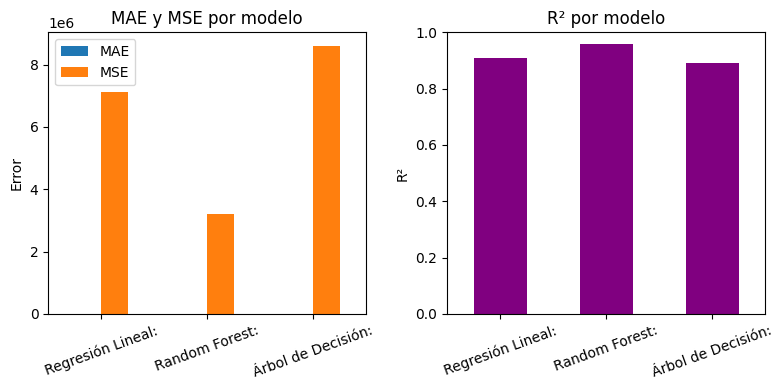

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(8,4))

df_resultados[['MAE', 'MSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('MAE y MSE por modelo')
axes[0].set_ylabel('Error')
axes[0].tick_params(axis='x', rotation=20)

df_resultados[['R2']].plot(kind='bar', ax=axes[1], color='purple', legend=False)
axes[1].set_title('R² por modelo')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


**Parte 6 – Interpretación**


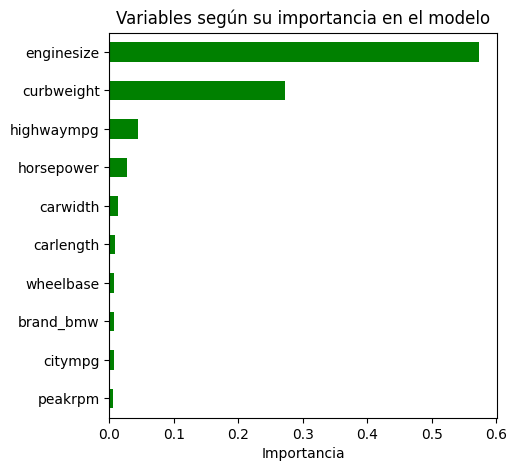

enginesize    0.572747
curbweight    0.272889
highwaympg    0.044720
horsepower    0.027313
carwidth      0.012480
carlength     0.009017
wheelbase     0.007291
brand_bmw     0.006760
citympg       0.006569
peakrpm       0.006179
dtype: float64

In [47]:
importancias = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(5,5))
importancias.head(10).sort_values().plot(kind='barh', color='green')
plt.title('Variables según su importancia en el modelo')
plt.xlabel('Importancia')
plt.show()

importancias.head(10)


**¿Qué tan bueno es el modelo?**
Los tres modelos entrenados obtuvieron un buen desempeño:

- **Regresión Lineal**: R² ≈ 0.91, MAE 
- **Árbol de Decisión**: R² ≈ 0.89, MAE
- **Random Forest**: R² ≈ 0.96, MAE 

Un R² de 0.96 en Random Forest indica que el modelo explica cerca del 96% de la variabilidad del precio de los vehículos a partir de sus características, y el error promedio de predicción (MAE) es de aproximadamente 1.250 USD, lo cual es razonable frente a precios que van desde 5.000 hasta 45.000 USD. En general, el modelo es bueno para fines predictivos y analíticos, aunque como todo modelo entrenado con relativamente pocos registros, su capacidad de generalizar a mercados o marcas no vistas es limitada.

**¿Qué variable parece influir más en la predicción?**

Según la importancia de variables del Random Forest, el tamaño del motor es la variable más immportante, seguida del peso del vehículo. Esto es coherente con el análisis de correlación de la Parte 2, donde estas mismas variables mostraban las correlaciones más fuertes con `price`. Curiosamente, la marca "importa" en el precio, pero no de forma directa. Importa porque determina qué tan grande hacen los motores. Por ejemplo: Jaguar no es cara "porque es Jaguar", es cara porque Jaguar decide fabricar autos con motores de 281 en promedio, mientras Chevrolet fabrica autos con motores de 80.

**¿Qué mejorarías si tuvieras más tiempo?**

- Haría una afinación de hiperparámetros para ajustar lo mejor posible los modelos.
- Buscaría recolectar más datos, puesto que los registros son relativamente pocos para sacar conclusiones escalables.
- Usaría más modelos para validar diferentes aspectos.
